# Assignment 4: Regularization

In [5]:
!git clone https://github.com/AustinChinn03/assignments.git

fatal: destination path 'assignments' already exists and is not an empty directory.


**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?

The penalty encourages the model to only incorporate variables with legitimate predictive power and minimize multicollinearity. By adding a penalty to the number of parameters, unnecessary variables will be eliminated as their presence increases MSE to a greater degree than their predictive ability reduces it.

2. How does regularization provide a way of exploring the bias-variance trade-off?

Without regularization, the model will have high bias and low variance, as parameters exhibiting multicollinearity or those that have little predictive power will explain noise specific to the training dataset. As the penalty for parameter number increases, bias is reduced at the expense of higher variance in predictions of the training dataset.

3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?

Ridge regression reduces the size of coefficients across the model and does not eliminate them, whereas LASSO often eliminates variables as alpha increases. Ridge regression is better for smaller datasets where all variables are desired, and LASSO is better for larger datasets where elimination of variables is acceptable.

4. How do we typically scale variables for use in regularized regression? Why?

Z-score scaling, because it prevents data on larger scales from being penalized more, when relative to the mean the data might have less variance.

5. How is the penalty $\alpha$ typically selected?

Cross-validating predictions across a range of alpha values, from which the alpha value that produces the lowest MSE can be chosen.

6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

No, the alpha value is only used for fitting, not for evaluation. When cross validating we are only concerned with using the model fitted using alpha to get MSE values.

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them.
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

In [9]:
# Q2.1

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV, lasso_path
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split\


cars = pd.read_csv("assignments/data/cars_hw.csv")

# Create Age variable
cars["Age"] = 2026 - cars["Make_Year"]

cars.head()


,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price,Age
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000,9
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000,10
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000,7
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000,9
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000,9


In [46]:
# Define X and y
X_raw = cars[["Mileage_Run", "Age"]]
y = cars["Price"]

# Create polynomial features
poly = PolynomialFeatures(degree=3, include_bias=False)
scaler = StandardScaler()

X_poly = poly.fit_transform(X_raw)
X_scaled = scaler.fit_transform(X_poly)

features = poly.get_feature_names_out(["Mileage_Run", "Age"])


In [47]:
# Q2.2

# Generate linear regression model
linreg = LinearRegression()
linreg.fit(X_scaled, y)

ols_coefs = pd.Series(linreg.coef_, index=features)
print(ols_coefs)

# Check sign of interaction term
print("\nInteraction coefficient sign:")
print(ols_coefs["Mileage_Run Age"])


Mileage_Run          9.117748e+05
Age                 -2.481722e+05
Mileage_Run^2       -2.072926e+05
Mileage_Run Age     -1.671212e+06
Age^2                3.505507e+05
Mileage_Run^3       -6.514490e+04
Mileage_Run^2 Age    3.388195e+05
Mileage_Run Age^2    7.167816e+05
Age^3               -2.100379e+05
dtype: float64

Interaction coefficient sign:
-1671212.3563918793


In [48]:
# Q2.3

# Run regression for range of alpha values
alphas = np.logspace(1, 3, 20)

lasso_cv = LassoCV(alphas=alphas, cv=20, max_iter=50000)
lasso_cv.fit(X_scaled, y)

print("Optimal alpha:", lasso_cv.alpha_)


Optimal alpha: 88.58667904100822


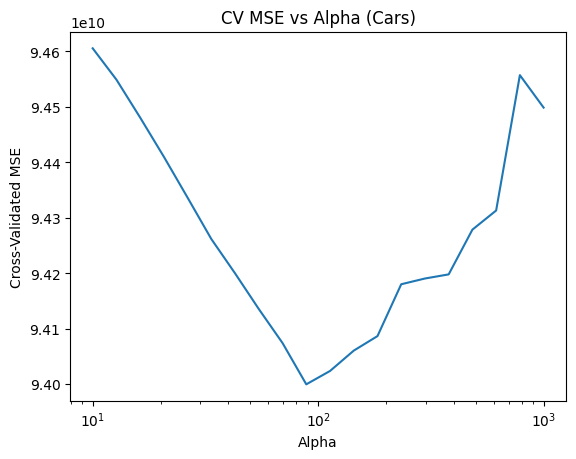

In [49]:
# Q2.4

# Calculate CV MSE for range of alpha values
mean_mse = np.mean(lasso_cv.mse_path_, axis=1)

# Plot MSE against alpha
plt.figure()
plt.plot(lasso_cv.alphas_, mean_mse)
plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("Cross-Validated MSE")
plt.title("CV MSE vs Alpha (Cars)")
plt.show()


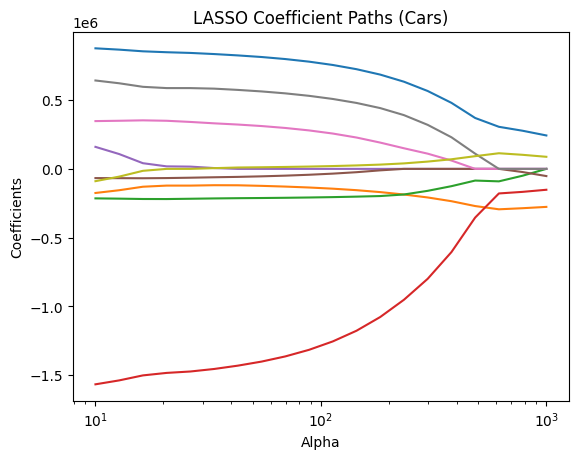

In [50]:
# Q2.5

# Get coefficients at each alpha value
alphas_lasso, coefs_lasso, _ = lasso_path(
    X_scaled,
    y,
    alphas=alphas,
    max_iter=50000
)

# Plot LASSO coefficient paths at values of alpha
plt.figure()
for i in range(coefs_lasso.shape[0]):
    plt.plot(alphas_lasso, coefs_lasso[i])
plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("Coefficients")
plt.title("LASSO Coefficient Paths (Cars)")
plt.show()


In [51]:
# Q2.6

# Get coefficients at optimal alpha
lasso_coefs = pd.Series(lasso_cv.coef_, index=features)

# List selected parameters
selected_features = lasso_coefs[lasso_coefs != 0]

print("Selected Features:")
print(selected_features)

# Calculate proportion of dropped features
zero_features = lasso_coefs[lasso_coefs == 0]
print("\nProportion set to zero:",
      len(zero_features) / len(lasso_coefs))

# Age^2 only parameter set to 0


Selected Features:
Mileage_Run          7.790762e+05
Age                 -1.339534e+05
Mileage_Run^2       -2.015634e+05
Mileage_Run Age     -1.322419e+06
Mileage_Run^3       -4.240952e+04
Mileage_Run^2 Age    2.715062e+05
Mileage_Run Age^2    5.415432e+05
Age^3                1.374220e+04
dtype: float64

Proportion set to zero: 0.1111111111111111


In [54]:
# Q2.7

# Create and display dataframe comparing OLS to LASSO coefficients
comparison = pd.DataFrame({
    "OLS": ols_coefs,
    "LASSO": lasso_coefs
})

comparison["Sign Change"] = np.sign(comparison["OLS"]) != np.sign(comparison["LASSO"])
comparison["Magnitude Increased"] = abs(comparison["LASSO"]) > abs(comparison["OLS"])

comparison.sort_values("LASSO").head(10)


,OLS,LASSO,Sign Change,Magnitude Increased
Mileage_Run Age,-1.671212e+06,-1.322419e+06,False,False
Mileage_Run^2,-2.072926e+05,-2.015634e+05,False,False
Age,-2.481722e+05,-1.339534e+05,False,False
Mileage_Run^3,-6.514490e+04,-4.240952e+04,False,False
Age^2,3.505507e+05,0.000000e+00,True,False
Age^3,-2.100379e+05,1.374220e+04,True,False
Mileage_Run^2 Age,3.388195e+05,2.715062e+05,False,False
Mileage_Run Age^2,7.167816e+05,5.415432e+05,False,False
Mileage_Run,9.117748e+05,7.790762e+05,False,False


**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

In [64]:
# Q3.1

# Import data
! git clone https://github.com/ds4e/scratchpad
%run ./scratchpad/get_data.py

heart = pd.read_csv(
    "data/heart_failure_clinical_records_dataset.csv"
    )

heart.head()


fatal: destination path 'scratchpad' already exists and is not an empty directory.


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [65]:
# Create polynomial features for continuous variables
y = heart["DEATH_EVENT"]
continuous_vars = ["age", "ejection_fraction", "serum_creatinine"]

poly_cont = PolynomialFeatures(degree=3, include_bias=False)
X_cont_poly = poly_cont.fit_transform(heart[continuous_vars])

cont_features = poly_cont.get_feature_names_out(continuous_vars)

# Create interaction terms for dummy/categorical variables
dummy_vars = ["anaemia", "diabetes", "high_blood_pressure", "smoking"]

poly_dummy = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_dummy_inter = poly_dummy.fit_transform(heart[dummy_vars])

dummy_features = poly_dummy.get_feature_names_out(dummy_vars)


In [66]:
# Combine and scale variables
X_combined = np.hstack([X_cont_poly, X_dummy_inter])
features = list(cont_features) + list(dummy_features)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_combined)


In [67]:
# Q3.2

# Run linear regression on heart model
linreg = LinearRegression()
linreg.fit(X_scaled, y)

# Print coefficients
ols_coefs = pd.Series(linreg.coef_, index=features)
print(ols_coefs.sort_values())


age^2                                    -3.678654
serum_creatinine^2                       -2.647041
ejection_fraction                        -2.192494
age ejection_fraction serum_creatinine   -1.577665
ejection_fraction^2 serum_creatinine     -1.270043
ejection_fraction^3                      -1.250341
serum_creatinine                         -0.853588
age^2 serum_creatinine                   -0.697522
age ejection_fraction                    -0.600918
age ejection_fraction^2                  -0.081206
smoking                                  -0.047943
diabetes                                 -0.034875
anaemia high_blood_pressure              -0.010004
high_blood_pressure                      -0.003787
anaemia                                   0.004008
anaemia diabetes                          0.009990
anaemia smoking                           0.020606
high_blood_pressure smoking               0.030482
diabetes high_blood_pressure              0.046474
diabetes smoking               

In [68]:
# Q3.3

# Run LASSO model across range of alpha values
alphas = np.logspace(-5, 5, 30)

lasso_cv = LassoCV(alphas=alphas, cv=20, max_iter=100000)
lasso_cv.fit(X_scaled, y)

print("Optimal alpha:", lasso_cv.alpha_)


Optimal alpha: 0.005736152510448681


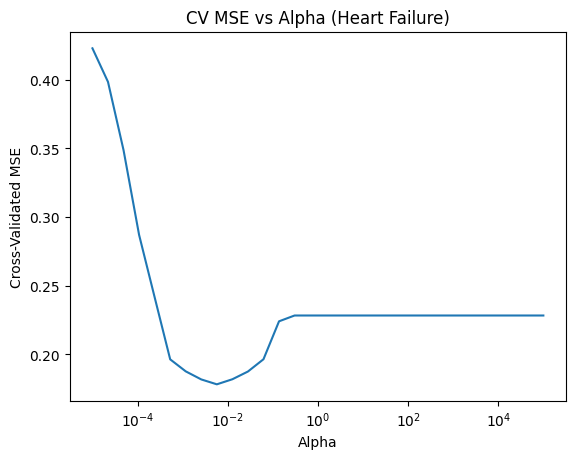

In [69]:
# Q3.4

# Calculate MSE as alpha varies
mean_mse = np.mean(lasso_cv.mse_path_, axis=1)

# Plot MSE against alpha
plt.figure()
plt.plot(lasso_cv.alphas_, mean_mse)
plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("Cross-Validated MSE")
plt.title("CV MSE vs Alpha (Heart Failure)")
plt.show()


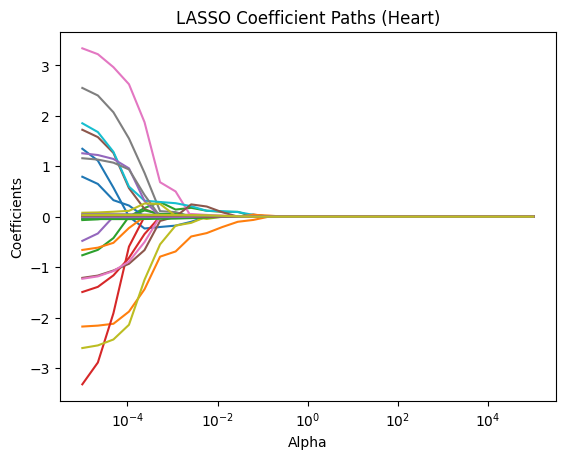

In [70]:
# Q3.5

# Get coefficients for each value of alpha
alphas_lasso, coefs_lasso, _ = lasso_path(
    X_scaled,
    y,
    alphas=alphas,
    max_iter = 100000
    )

# Plot coefficient paths for heart dataset
plt.figure()
for i in range(coefs_lasso.shape[0]):
    plt.plot(alphas_lasso, coefs_lasso[i])

plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("Coefficients")
plt.title("LASSO Coefficient Paths (Heart)")
plt.show()


In [71]:
# Q3.6

# Get coefficients for optimal alpha
lasso_coefs = pd.Series(lasso_cv.coef_, index=features)

# Print selected parameter coeffiecients
selected_features = lasso_coefs[lasso_coefs != 0]

print("Selected Features:")
print(selected_features)

# Calculate proportion of parameters dropped
zero_features = lasso_coefs[lasso_coefs == 0]

print("\nProportion set to zero:",
      len(zero_features) / len(lasso_coefs))


Selected Features:
ejection_fraction                      -0.326124
serum_creatinine                        0.117426
age^3                                   0.116214
ejection_fraction^3                     0.200750
ejection_fraction^2 serum_creatinine    0.034419
serum_creatinine^3                     -0.045558
anaemia                                 0.013163
smoking                                -0.019828
anaemia diabetes                        0.000310
diabetes high_blood_pressure            0.024535
diabetes smoking                        0.017410
high_blood_pressure smoking             0.025812
dtype: float64

Proportion set to zero: 0.5862068965517241


In [73]:
# Create comparison table of OLS and LASSO coefficients
comparison = pd.DataFrame({
    "OLS": ols_coefs,
    "LASSO": lasso_coefs
})

comparison["Sign Change"] = np.sign(comparison["OLS"]) != np.sign(comparison["LASSO"])
comparison["Magnitude Increased"] = abs(comparison["LASSO"]) > abs(comparison["OLS"])

comparison.sort_values("LASSO").head(30)

# Notable changes include a reduction in magnitude in smoking variable and
# interaction variables. Smoking alone is negative in both, but may just be
# scaling interaction variables. Anaemia increases in magnitude, which is
# interesting. 3 creatinine parameters change signs, which is interesting. They
# may have been being used to explain noise as they are relatively small in
# magnitude.


,OLS,LASSO,Sign Change,Magnitude Increased
ejection_fraction,-2.192494,-0.326124,False,False
serum_creatinine^3,0.072156,-0.045558,True,False
smoking,-0.047943,-0.019828,False,False
age,1.539156,-0.000000,True,False
ejection_fraction^2,3.430976,0.000000,True,False
age serum_creatinine,1.841563,0.000000,True,False
age^2,-3.678654,0.000000,True,False
age ejection_fraction,-0.600918,-0.000000,True,False
age serum_creatinine^2,1.284099,-0.000000,True,False
age^2 ejection_fraction,0.908026,0.000000,True,False


**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?

$$
J(b_0​, b_1​)=\frac{1}{n} ​\sum^n(\tilde{y}_i ​​− b_0 − b_1​\tilde{x}_i​)^2 + \alpha b_1^2​
$$

2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.

With respect to b0:
$$
\frac{​\delta b_0}{​\delta J​}=\frac{-2}{n}\sum​^n(\tilde{y}_i ​− b_0 ​− b_i​\tilde{x}_i​)
$$

With respect to b1:
$$
\frac{\delta b_1}{​\delta J​}​=frac{-2}{n}\sum​^n \tilde{x}_i (\tilde{y}_i ​− b1_1\tilde{x}_i​) + 2\alpha b_1​
$$

Solve for b1
$$
b_1 ​= \sum^n \tilde{x}_i​\tilde{y}_​i​​ / \sum^n \tilde{x}_i^2​ + n\alpha
$$

3. How does increasing $\alpha$ change the slope coefficient?

The denominator increases, driving the relationship toward zero and flattening the equation

4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

The LASSO penalty is not differentiable at 0. This means that when covariance is less than n*alpha, it is optimal to set the coefficient to zero.
